# Load Data

In [4]:
import pandas as pd

In [5]:
df = pd.read_excel(r"C:\Users\Dell\Downloads\archive(1)\E-Commerce Orders.csv.xlsx")

In [6]:
print(df.head())

     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003 2023-10-15     C33540    Chair         1     273.19   
4  ORD200004 2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral      302.70  
2   FREESHIP  

# Check Structure

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

# descriptive statistics

In [8]:
print(df.describe())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


# Check Null Values

In [9]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


# Check Duplicates

In [10]:
df.duplicated().sum()

np.int64(0)

# Handle ONLY CouponCode
- missing means: customer did not use coupon

In [11]:
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

# Convert Date

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

# Create Useful Columns

In [13]:
df['Month'] = df['Date'].dt.month_name()

In [14]:
df['Year'] = df['Date'].dt.year

In [15]:
df['DayName'] = df['Date'].dt.day_name()

# Standardize Text Columns

Real datasets me:

cod
COD
Cash on Delivery - mixed

In [18]:
df['PaymentMethod'] = df['PaymentMethod'].str.strip().str.title()

df['OrderStatus'] = df['OrderStatus'].str.strip().str.title()

df['ReferralSource'] = df['ReferralSource'].str.strip().str.title()

In [19]:
print(df[df['Quantity'] <= 0])

print(df[df['UnitPrice'] <= 0])

print(df[df['TotalPrice'] <= 0])

Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice, Month, Year, DayName]
Index: []
Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice, Month, Year, DayName]
Index: []
Empty DataFrame
Columns: [OrderID, Date, CustomerID, Product, Quantity, UnitPrice, ShippingAddress, PaymentMethod, OrderStatus, TrackingNumber, ItemsInCart, CouponCode, ReferralSource, TotalPrice, Month, Year, DayName]
Index: []


# Verify Revenue

In [16]:
df['CalculatedPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
print(df[['TotalPrice', 'CalculatedPrice']].head())

   TotalPrice  CalculatedPrice
0     2853.10          2853.10
1      302.70           302.70
2     2753.40          2753.40
3      273.19           273.19
4     2504.04          2504.04


In [19]:
df['PriceMatch'] = df['TotalPrice'] == df['CalculatedPrice']

print(df['PriceMatch'].value_counts())

PriceMatch
True     1093
False     107
Name: count, dtype: int64


# Create Difference Column 
- they may represent:

discounted orders
promotional pricing

In [21]:
df['PriceDifference'] = df['TotalPrice'] - df['CalculatedPrice']
print(df['PriceDifference'])

0       0.000000e+00
1       0.000000e+00
2       4.547474e-13
3       0.000000e+00
4       0.000000e+00
            ...     
1195    0.000000e+00
1196    0.000000e+00
1197    0.000000e+00
1198    0.000000e+00
1199    0.000000e+00
Name: PriceDifference, Length: 1200, dtype: float64


# Inspect Mismatch Rows

In [22]:
mismatch_df = df[df['PriceMatch'] == False]

print(mismatch_df[
[
'Quantity',
'UnitPrice',
'CalculatedPrice',
'TotalPrice',
'CouponCode'
]
].head())

    Quantity  UnitPrice  CalculatedPrice  TotalPrice CouponCode
2          5     550.68          2753.40     2753.40   FREESHIP
10         5     625.97          3129.85     3129.85   WINTER15
11         3      49.14           147.42      147.42     SAVE10
32         5     536.72          2683.60     2683.60  No Coupon
41         3     611.45          1834.35     1834.35   FREESHIP


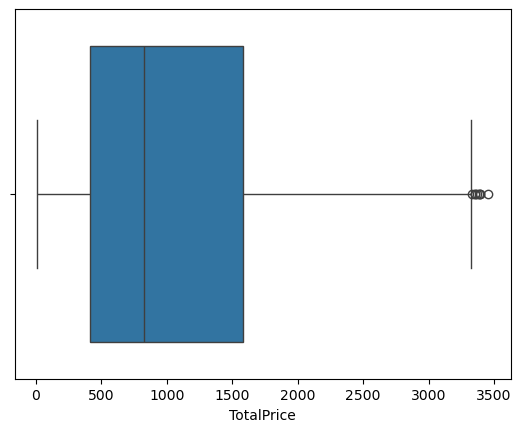

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['TotalPrice'])

plt.show()

In [25]:
df.to_csv("cleaned_orders.csv", index=False)

In [27]:
import os
print(os.getcwd())

C:\Users\Dell
